In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\lenovo\Desktop\customer churn prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Rows and Columns :", df.shape)

Rows and Columns : (7043, 21)


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

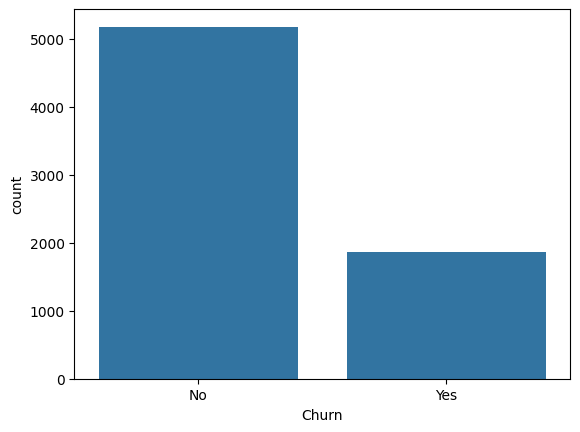

In [10]:
sns.countplot(x="Churn", data=df)
plt.show()

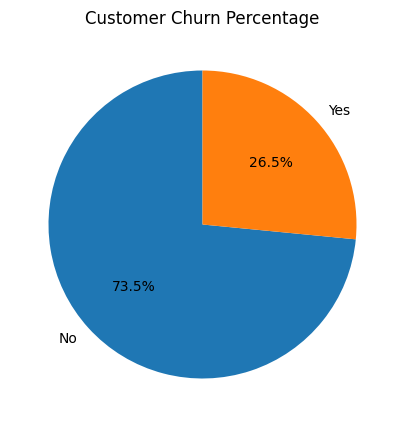

In [11]:
plt.figure(figsize=(5,5))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Customer Churn Percentage")

plt.show()

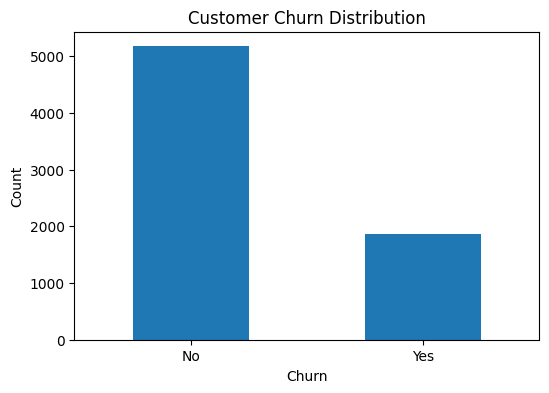

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

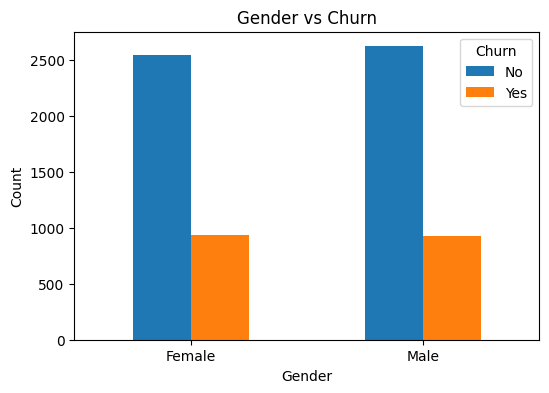

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab(df["gender"], df["Churn"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

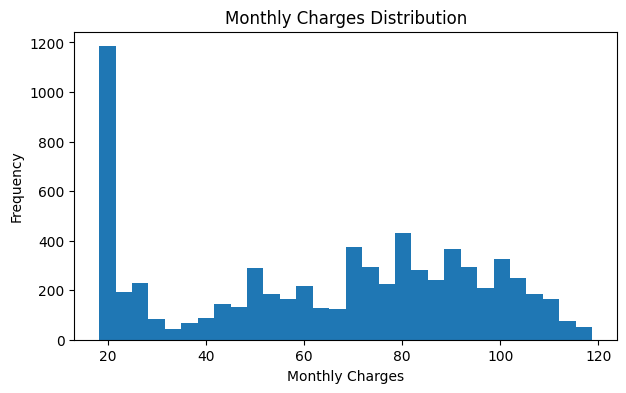

In [14]:
plt.figure(figsize=(7,4))

plt.hist(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

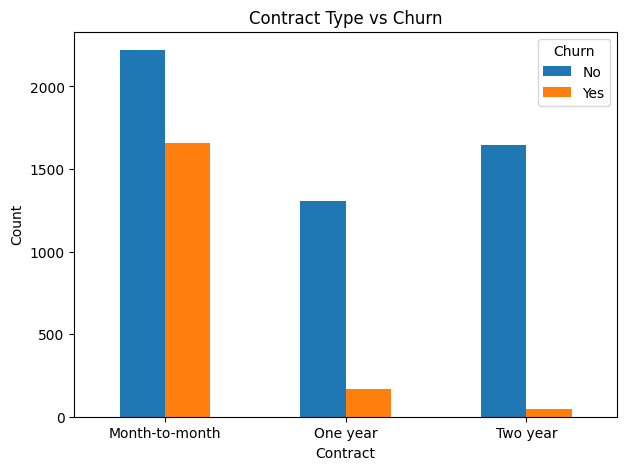

In [15]:
pd.crosstab(df["Contract"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [16]:

df.drop("customerID", axis=1, inplace=True)


df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.value_counts())

(7043, 19)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [19]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print(categorical_cols)
print(numerical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numerical_cols
        )
    ]
)

In [21]:
from sklearn.linear_model import LogisticRegression


pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_pred = pipeline.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8048261178140526


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7920511000709723
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.7971050551648494


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [10, 15, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 500}
0.8031572842280784


In [39]:
import joblib

best_model = grid.best_estimator_

joblib.dump(best_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [28]:
from xgboost import XGBClassifier

In [29]:
import sys
print(sys.executable)

c:\Users\lenovo\Desktop\customer churn prediction\venv\Scripts\python.exe


In [30]:
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [33]:
y_train_encoded = y_train.map({"No": 0, "Yes": 1})
y_test_encoded = y_test.map({"No": 0, "Yes": 1})

xgb_pipeline.fit(X_train, y_train_encoded)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
y_pred_xgb = xgb_pipeline.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_xgb = pd.Series(y_pred_xgb).map({0: "No", 1: "Yes"}).values
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7899219304471257
              precision    recall  f1-score   support

          No       0.84      0.88      0.86      1035
         Yes       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [38]:
import joblib

joblib.dump(xgb_pipeline, "../models/churn_xgb.pkl")

['../models/churn_xgb.pkl']

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train_encoded)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 4, 'model__n_estimators': 300}
Best CV Score: 0.8015602812288712


In [43]:
best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)
y_pred = pd.Series(y_pred).map({0: "No", 1: "Yes"}).values


print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8062455642299503
              precision    recall  f1-score   support

          No       0.84      0.91      0.87      1035
         Yes       0.68      0.51      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409

              precision    recall  f1-score   support

          No       0.84      0.91      0.87      1035
         Yes       0.68      0.51      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [44]:
import joblib

joblib.dump(best_xgb, "../models/churn_xgboost.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
